# Bootstrap Testbench in Python

This notebook implements a Python-based testbench for the design and verification of the bootstrap Sample-and-Hold circuit used in the 10-bit SAR ADC developed for Chipathon 2026. It automates NGspice simulations while providing a convenient environment for data processing, visualization, and performance evaluation.

The workflow assumes that the SPICE netlist has already been generated from Xschem. After the netlist is available, all simulation parameters are controlled directly from Python. The notebook is organized into independent sections covering **project configuration, simulation setup, waveform import and plotting, output spectrum analysis, and ENOB calculation**.

## Project configuration:

The following libraries are used throughout the notebook. They provide utilities for file management, SPICE netlist editing, simulation execution, data handling, and result visualization.

In [127]:
from pathlib import Path            # Manage file and directory paths
import subprocess                   # Execute external programs (NGspice)
import re                           # Search and replace netlist parameters
import warnings                     # Messages for the set_params function

import numpy as np                  # Numerical computations
import pandas as pd                 # Data import and manipulation
import matplotlib.pyplot as plt     # Plotting
from matplotlib.ticker import EngFormatter  # Engineering notation for axes

The paths shown below correspond to the **IIC Docker container version 2026.06**, where simulation files generated by Xschem are stored under `/headless/.xschem/simulations` and NGspice is installed in `/foss/tools/bin/ngspice`. If a different environment is used, these paths should be updated accordingly.

In [128]:
# Working directory containing the simulation files
WORK_DIR = Path("/headless/.xschem/simulations")

# NGspice executable
NGSPICE = "/foss/tools/bin/ngspice"

# Default plotting style
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Nimbus Roman"],
    "font.size": 11,
})

Simulation parameters are defined in the SPICE netlist and updated automatically from Python, avoiding manual file edits. If a parameter is also redefined inside the `.control` block with a `let` statement, both definitions are updated to keep them consistent.

In [129]:
def set_params(netlist, **params):
    """
    Update multiple settings in a SPICE netlist in a single write operation.

    Raises a warning if a parameter is not found in the netlist
    (to avoid silent failures).
    """

    netlist = Path(netlist)
    text = netlist.read_text()

    for name, value in params.items():

        # -------------------------
        # Process corner
        # -------------------------
        if name.lower() == "corner":

            valid_corners = {
                "typical",
                "ss",
                "sf",
                "fs",
                "ff",
                "statistical",
            }

            if str(value).lower() not in valid_corners:
                raise ValueError(
                    f"Invalid corner '{value}'. "
                    f"Valid options are: {', '.join(sorted(valid_corners))}."
                )

            text, n = re.subn(
                r"(^\s*\.lib\s+\S+\s+)\S+\s*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n == 0:
                warnings.warn(
                    f"[set_params] Corner not updated: no .lib line found in netlist.",
                    RuntimeWarning,
                )

        # -------------------------
        # Temperature
        # -------------------------
        elif name.lower() == "temp":

            text, n = re.subn(
                r"(^\s*\.temp\s+).*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n == 0:
                warnings.warn(
                    f"[set_params] Temperature not updated: no .temp line found.",
                    RuntimeWarning,
                )

        # -------------------------
        # Params and control variables
        # -------------------------
        else:

            text_param, n1 = re.subn(
                rf"(^\s*\.param\s+{re.escape(name)}\s*=\s*).*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            text_let, n2 = re.subn(
                rf"(^\s*let\s+{re.escape(name)}\s*=\s*).*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            text = text_param if n1 > 0 else text_let

            if n1 + n2 == 0:
                warnings.warn(
                    f"[set_params] Parameter '{name}' not found in .param or let definitions.",
                    RuntimeWarning,
                )

    netlist.write_text(text)

## **Simulation setup and run**

In [130]:
# Sampling parameters
Fs = 5e6
Ns = 1024
Nc = 103

# Testbench parameters
PROCESS = "typical"
VDD = 3.3
TEMP = 27
Cload = "1p"
Nspare = 5

The simulation is launched from the working directory so that all output files, such as exported waveforms, are generated in the work directory. Finally, the NGspice console output is printed to facilitate debugging and verify that the simulation completed successfully.

In [131]:
# SPICE netlist
NETLIST = WORK_DIR / "tb_bootstrapped.spice"

# Simulation parameters
SIM_CONFIG = {
    "corner": PROCESS,
    "temp": TEMP,
    "VDD": VDD,
    "Fs": f"{Fs:g}",
    "Ns": Ns,
    "Nc": Nc,
    "Cload": Cload,
    "Nspare": Nspare,
}

set_params(NETLIST, **SIM_CONFIG)

# Run NGspice in batch mode
result = subprocess.run(
    [NGSPICE, "-b", str(NETLIST)],
    cwd=WORK_DIR,
    capture_output=True,
    text=True,
)

# Display the NGspice output
print(result.stdout)

# Print the error log if the simulation failed
if result.returncode != 0:
    print(result.stderr)


Note: Compatibility modes selected: hs a


Circuit: ** sch_path: /foss/designs/chipathon-2026-onchipsar/designs/sar_adc/samplehold/bootstrapped/xschem/tb_bootstrapped.sch

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver

Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
vdd                                        3.3
vss                                          0
vin                                       1.65
clk                                          0
vout                                 0.0874613
x2.net1                            1.08956e-09
x2.clkn                                    3.3
x2.cc                                      3.3
x2.vx                              2.17912e-09
x2.vcc                             3.69521e-09
x2.vc                                      3.3
vclk#branch                                  0
vin#branch     

## Waveform import

The transient data exported by NGspice is imported into a Pandas DataFrame with descriptive column names. Since `wrdata` generates one time column per waveform, duplicated time vectors are verified for consistency and merged into a single `time` column for subsequent analysis.

In [132]:
data = pd.read_csv(
    WORK_DIR / "tb_bootstrapped.csv",
    sep=r"\s+",
    header=None,
    names=[
        "t_vin", "vin",
        "t_vout", "vout",
        "t_clk", "clk"
    ]
)

# Verify that all time columns are equivalent
time_match = (
    np.allclose(data["t_vin"], data["t_vout"]) and
    np.allclose(data["t_vin"], data["t_clk"])
)

if time_match:
    data = (
        data.rename(columns={"t_vin": "time"})
            [["time", "vin", "vout", "clk"]]
    )
else:
    raise ValueError("Time columns are not identical.")

print(data.head())

           time       vin      vout  clk
0  0.000000e+00  1.650000  0.087461  0.0
1  8.333330e-10  1.654345  1.125875  3.3
2  1.666666e-09  1.658690  1.641399  3.3
3  2.499999e-09  1.663035  1.661746  3.3
4  3.333332e-09  1.667380  1.666194  3.3


## Plot Waveforms

To simplify visualization, only the first input signal period is displayed. The period is computed automatically from the simulation parameters, and the resulting plots show the input voltage, sampled output voltage, and sampling clock on a common time axis.


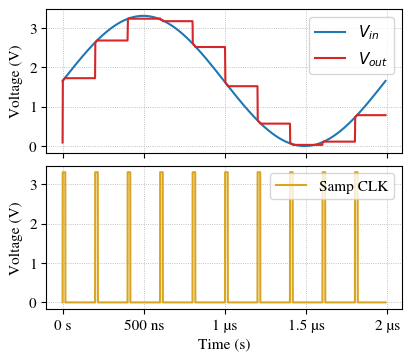

In [133]:
# Compute the input frequency and period
Fin = Nc / Ns * Fs
Tin = 1 / Fin

# Keep only the first input period
data_plot = data[data["time"] <= Tin]

# Create the figure
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(4, 3.5),
    sharex=True,
    constrained_layout=True,
)

# Plot the input and output voltages
ax1.plot(data_plot["time"], data_plot["vin"], label=r"$V_{in}$", color="tab:blue")
ax1.plot(data_plot["time"], data_plot["vout"], label=r"$V_{out}$", color="tab:red")

ax1.set_ylabel("Voltage (V)")
ax1.grid(True, linestyle=":", linewidth=0.6)
ax1.legend(loc="upper right")

# Plot the sampling clock
ax2.plot(data_plot["time"], data_plot["clk"], label="Samp CLK", color="goldenrod")

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (V)")
ax2.grid(True, linestyle=":", linewidth=0.6)
ax2.legend(loc="upper right")

# Display the time axis using engineering notation
ax2.xaxis.set_major_formatter(EngFormatter(unit="s"))

plt.show()

## Output FFT

The output waveform is sampled at the same instants as the switched-capacitor circuit, starting after the initial discarded cycles to avoid switching transients. The sampled sequence is then processed using a normalized FFT to obtain the one-sided power spectrum for performance analysis.

In [134]:
# Sampling parameters
Ts = 1 / Fs
Ton = Ts / 12

# First sampling instant after the discarded cycles
t0 = Nspare * Ts + 2 * Ton

# Generate the sampling instants
sample_times = t0 + np.arange(Ns) * Ts

# Interpolate the transient waveform at the sampling instants
vout_samples = np.interp(
    sample_times,
    data["time"],
    data["vout"],
)

# Compute the normalized FFT
fft = np.fft.fft(vout_samples, n=Ns)
fft /= Ns

# Keep the one-sided spectrum
fft = fft[: Ns // 2 + 1]
fft[1:-1] *= 2

# Frequency axis
f = np.fft.rfftfreq(Ns, d=Ts)

# Power spectrum
PSD = np.abs(fft) ** 2

# Power spectrum in dB
PSD_db = 10 * np.log10(np.maximum(PSD, 1e-20))

The one-sided FFT computed in the previous section is displayed as a function of frequency. This spectrum provides a convenient representation of the sampled output and serves as the basis for evaluating the S&H performance.

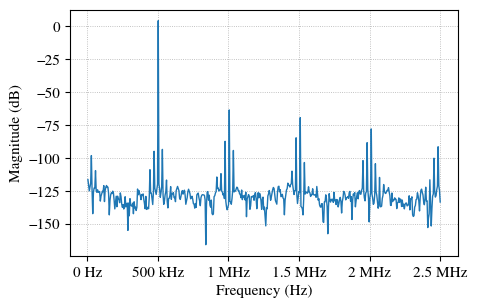

In [135]:
# Create the figure
fig, ax = plt.subplots(figsize=(5, 3.2))

# Plot the one-sided spectrum
ax.plot(
    f[1:],
    PSD_db[1:],
    color="tab:blue",
    linewidth=1,
)

# Use engineering notation for the frequency axis
ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")

# Configure the grid
ax.grid(
    True,
    which="both",
    linestyle=":",
    linewidth=0.6,
)

plt.show()

## Compute SNDR and ENOB

The sampled spectrum is used to estimate the Signal-to-Noise-and-Distortion Ratio (SNDR) and the Effective Number of Bits (ENOB). The computation excludes the DC component and treats the fundamental tone as the signal, while the remaining spectral power is considered noise and distortion.

In [136]:
def compute_enob(PSD, f, fin, fs, Nfft, bandwidth=None):
    """
    Compute SNDR and ENOB over the selected frequency region.

    If bandwidth is None, the full spectrum is used.
    Otherwise, only frequencies below the specified bandwidth
    are included in the calculation.
    """

    df = fs / Nfft

    # Select the frequency region
    if bandwidth is None:
        region_mask = np.ones_like(f, dtype=bool)
    else:
        region_mask = np.abs(f) < bandwidth

    # Identify the fundamental tone and DC component
    fundamental_mask = np.abs(f - fin) < df / 2
    dc_mask = (f == 0)

    fundamental_mask &= region_mask
    dc_mask &= region_mask

    # Compute the signal, noise, and distortion powers
    total_power = np.sum(PSD[region_mask])
    fundamental_power = np.sum(PSD[fundamental_mask])
    dc_power = np.sum(PSD[dc_mask])

    noise_dist_power = total_power - fundamental_power - dc_power

    # Compute SNDR and ENOB
    sndr = 10 * np.log10(fundamental_power / noise_dist_power)
    enob = (sndr - 1.7609) / 6.0206

    return sndr, enob


# Compute SNDR and ENOB over the full Nyquist band
sndr_full, enob_full = compute_enob(
    PSD,
    f,
    Fin,
    Fs,
    Ns,
)

# Display the results
print("============== RESULTS ==============")
print(f"SNDR : {sndr_full:.4f} dB")
print(f"ENOB : {enob_full:.4f} bits")

============== RESULTS ==============
SNDR : 66.6306 dB
ENOB : 10.7746 bits
